In [1]:
import pandas as pd
import nltk 
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk import RegexpParser
from nltk.tokenize import sent_tokenize 
from nltk import Tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from transformers import TFBertModel, AutoTokenizer
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings
import time
from concurrent.futures import ThreadPoolExecutor
from transformers import logging
from matplotlib.ticker import MaxNLocator
import math
from transformers import pipeline
from functools import partial
from scipy.optimize import curve_fit
import json
import itertools
import networkx as nx
import statsmodels.api as sm

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import SpectralClustering
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score, silhouette_samples
from gensim.models import CoherenceModel
from gensim.models.ldamodel import LdaModel
from gensim.utils import simple_preprocess

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from itertools import combinations
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
logging.set_verbosity_error()  # disable warnings from transformer, hugging face package.

In [2]:
## get all the stories.  nine stories in total.
story_all = [] 

data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v1-pool.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v2-lake.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v1-rookie.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v2-catlady.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/panic.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v1-park.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v2-church.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/stein.pkl")
story_all.append(data)

In [3]:
## use the clauses in the original dataset.
story_processed_all = [story_all[i]['segmentation'] for i in np.arange(9)]
story_processed_marked = [string.split("\n") for string in story_processed_all]  # split into single clauses.
story_processed_all_num = story_processed_marked

story_processed_all = [[item[3:] if item[2] == "." 
                        else item[2:] if item[1] == "."
                        else item[4:] for item in story_processed_marked[story]] for story in np.arange(9)]

recall_processed_all = [story_all[i]['recalls segmented'] for i in np.arange(len(story_processed_all))]
recall_processed_marked = [[participant.split("\n") for participant in recall_processed_all[story]]
                        for story in np.arange(9)]
recall_processed_all = [[ [element[3:] if len(element) > 2 and element[2] == "." else
                           element[2:] if len(element) > 2 and element[1] == "." else
                           element[4:] if len(element) > 2 else
                           ""  for element in participant] for participant in recall_processed_marked[story]]
                        for story in np.arange(9)]

score_processed_all = [story_all[i]['recall scores'] for i in np.arange(len(story_processed_all))]
for i in np.arange(len(score_processed_all)):
    recall_score_each = score_processed_all[i].values
    score_processed_all[i] = recall_score_each.tolist()

In [4]:
## three more stories added to the analysis.
story_additional = [] 
recall_additional = []

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-segments.csv", encoding='utf-8')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-recalls_segmented.csv", encoding='utf-8')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/do-something-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/dosomething-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

In [5]:
additional_story_processed = []
additional_recall_processed = [[] for _ in np.arange(3)]
score_processed_additional = []

for i in np.arange(3):
    # the original story in segment.
    story = story_additional[i]['segment_text']
    story_as_list = story.tolist()
    additional_story_processed.append(story_as_list)

    # get the recall text by each participant.
    recall = recall_additional[i]
    recall_id = recall['recall_id']
    recall_id_set = list(set(recall_id))
    for j in recall_id_set:
        recall_participant = recall[recall['recall_id'] == j]
        recall_content = recall_participant['clause_text']
        recall_as_list = recall_content.tolist()
        additional_recall_processed[i].append(recall_as_list)

    # get the recall score of each narrative clause. - the final score in the csv directly.
    score_processed_additional.append(story_additional[i]['proc'])
    score_processed_add = [series_item.tolist() for series_item in score_processed_additional]
    score_processed = [[float(p.strip('%')) for p in percent_list] 
                                      for percent_list in score_processed_add]

In [6]:
## add the new data to the dataset.
story_processed_all = story_processed_all + additional_story_processed
# print(len(story_processed_all))

story_processed_all_num = story_processed_all_num + additional_story_processed

recall_processed_all = recall_processed_all + additional_recall_processed
# print(len(recall_processed_all))

clauses = [len(story_processed_all[i]) for i in np.arange(len(story_processed_all))]
print("clauses in each story: ", clauses )

clauses in each story:  [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]


In [7]:
model = SentenceTransformer('all-MiniLM-L6-v2')

story_emb_all = [model.encode(story) for story in story_processed_all]

recall_emb_all = [[model.encode(participant) for participant in story if len(participant)>2]
                    for story in recall_processed_all]

## find the optimal K for clustering.

In [8]:
## PR ratio crtierion.
thresholds = [0.05, 0.10, 0.15]

results = {}   # keyed by threshold

for th in thresholds:
    selected_indices_all = []
    story_emb_select     = []
    clauses_select       = []

    for story in range(12):
        story_embs  = np.array(story_emb_all[story])
        story_norms = story_embs / (np.linalg.norm(story_embs, axis=1, keepdims=True) + 1e-10)

        participants   = recall_emb_all[story]
        n_participants = len(participants)
        recall_counts  = np.zeros(len(story_embs))

        for p_embs in participants:
            if len(p_embs) == 0:
                continue
            p_embs  = np.array(p_embs)
            p_norms = p_embs / (np.linalg.norm(p_embs, axis=1, keepdims=True) + 1e-10)
            sims     = p_norms @ story_norms.T
            best_idx = np.argmax(sims, axis=1)
            for idx in best_idx:
                recall_counts[idx] += 1

        recall_rate = recall_counts / n_participants
        mask        = recall_rate >= th

        story_emb_select.append(story_embs[mask])
        clauses_select.append(int(mask.sum()))
        selected_indices_all.append(np.where(mask)[0].tolist())

    results[th] = {
        'story_emb_select':     story_emb_select,
        'clauses_select':       clauses_select,
        'selected_indices_all': selected_indices_all,
    }
    print(f"th = {th:.2f} — clauses remaining: {clauses_select}")


th = 0.05 — clauses remaining: [19, 18, 18, 32, 32, 54, 50, 54, 102, 101, 148, 76]
th = 0.10 — clauses remaining: [18, 17, 18, 29, 31, 48, 44, 47, 74, 74, 92, 64]
th = 0.15 — clauses remaining: [18, 15, 17, 27, 26, 45, 38, 39, 57, 49, 62, 48]


In [9]:
# calculate the covariance matrix with each data as the column and row. 
   ## -- cluster each PR possible number of clusters, and compare them by coherence and between-group differences later.
def covariance_matrix(X):
    X_centered = X - np.mean(X, axis=0)
    
    d = X.shape[0]    # number of rows. used N-1, no matter how you get the cov matrix.
    cov = (X_centered.T @ X_centered) / (d - 1)     # 384x384 cov matrix.
    return cov

# Precompute KMeans labels for all narratives across all K values
kmeans_results = {}   # keyed by threshold

for th in thresholds:
    story_emb_select = results[th]['story_emb_select']
    clauses_select   = results[th]['clauses_select']

    labels_all_narratives   = []
    centers_all_narratives  = []
    test_cluster_narratives = []

    for story in range(12):
        print(f"th={th:.2f}  Narrative {story+1} starts...")
        X = story_emb_select[story]
        num_clauses = clauses_select[story]
        k_range = list(range(2, num_clauses + 1))

        labels_all  = []
        centers_all = []

        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(X)
            labels_all.append(kmeans.labels_)
            centers_all.append(kmeans.cluster_centers_)

        labels_all_narratives.append(labels_all)
        centers_all_narratives.append(centers_all)
        test_cluster_narratives.append([k_range])

    kmeans_results[th] = {
        'labels_all_narratives':   labels_all_narratives,
        'centers_all_narratives':  centers_all_narratives,
        'test_cluster_narratives': test_cluster_narratives,
    }


th=0.05  Narrative 1 starts...
th=0.05  Narrative 2 starts...
th=0.05  Narrative 3 starts...
th=0.05  Narrative 4 starts...
th=0.05  Narrative 5 starts...
th=0.05  Narrative 6 starts...
th=0.05  Narrative 7 starts...
th=0.05  Narrative 8 starts...
th=0.05  Narrative 9 starts...
th=0.05  Narrative 10 starts...
th=0.05  Narrative 11 starts...
th=0.05  Narrative 12 starts...
th=0.10  Narrative 1 starts...
th=0.10  Narrative 2 starts...
th=0.10  Narrative 3 starts...
th=0.10  Narrative 4 starts...
th=0.10  Narrative 5 starts...
th=0.10  Narrative 6 starts...
th=0.10  Narrative 7 starts...
th=0.10  Narrative 8 starts...
th=0.10  Narrative 9 starts...
th=0.10  Narrative 10 starts...
th=0.10  Narrative 11 starts...
th=0.10  Narrative 12 starts...
th=0.15  Narrative 1 starts...
th=0.15  Narrative 2 starts...
th=0.15  Narrative 3 starts...
th=0.15  Narrative 4 starts...
th=0.15  Narrative 5 starts...
th=0.15  Narrative 6 starts...
th=0.15  Narrative 7 starts...
th=0.15  Narrative 8 starts...
th

#### Compare within-group coherence and between-group differences. Find the largest coherence + difference score.

In [43]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

def cluster_coherence(embeddings):
    if len(embeddings) < 2:
        return 1.0
    sim_matrix = cos_sim(embeddings)
    n = len(embeddings)
    pair_sims = [sim_matrix[i, j] for i in range(n) for j in range(i+1, n)]
    return np.mean(pair_sims)

def covariance_matrix(X):
    X_centered = X - np.mean(X, axis=0)
    return (X_centered.T @ X_centered) / (X.shape[0] - 1)

def calculate_participation_ratio(cov_matrix):
    eigenvalues = np.linalg.eigvalsh(cov_matrix)
    return (np.sum(eigenvalues)**2) / np.sum(eigenvalues**2)

pr_results = {}

for th in thresholds:
    region_param           = 1 - th
    clauses_select         = results[th]['clauses_select']
    centers_all_narratives = kmeans_results[th]['centers_all_narratives']

    test_cluster   = [list(range(2, clauses_select[i]+1)) for i in range(12)]
    optimal_n_all  = []
    story_results  = []
    pr_ratio_lines = []

    for story in range(12):
        centers_all = centers_all_narratives[story]
        k_range     = test_cluster[story]

        pr_ratio_line = []
        for index, centers in enumerate(centers_all):
            cov = covariance_matrix(np.array(centers))
            pr  = calculate_participation_ratio(cov)
            pr_ratio_line.append(pr / (index + 2))

        pr_ratio_line = np.array(pr_ratio_line)
        pr_ratio_lines.append(pr_ratio_line)

        max_pr         = pr_ratio_line.max()
        k_at_max_pr    = k_range[np.argmax(pr_ratio_line)]
        k_in_pr_region = [k_range[i] for i, val in enumerate(pr_ratio_line)
                          if val >= max_pr * region_param]

        # first K with maximum combined score within PR region
        combined   = kmeans_results[th]['combined_all_narratives'][story]
        region_idx = [i for i, k in enumerate(k_range) if k in k_in_pr_region]
        best_i     = region_idx[np.argmax([combined[i] for i in region_idx])]
        optimal_n  = k_range[best_i]
        optimal_n_all.append(optimal_n)

        labels_at_opt = kmeans_results[th]['labels_all_narratives'][story][optimal_n - 2]
        cluster_sizes = [int(np.sum(labels_at_opt == c)) for c in range(optimal_n)]

        story_results.append({
            'story':          story + 1,
            'k_at_max_pr':    k_at_max_pr,
            'k_in_pr_region': k_in_pr_region,
            'optimal_n':      optimal_n,
            'cluster_sizes':  cluster_sizes,
        })

        print(f"th={th:.2f}  Story {story+1}: optimal K={optimal_n}  "
              f"PR region={k_in_pr_region}  cluster sizes={cluster_sizes}")

    pr_results[th] = {
        'optimal_n_all':  optimal_n_all,
        'story_results':  story_results,
        'pr_ratio_lines': pr_ratio_lines,
    }

    print(f"\n── th={th:.2f} summary ──")
    print(f"{'Story':<8} {'K at max PR':<14} {'K in PR region':<30} {'Optimal K'}")
    print("-" * 65)
    for r in story_results:
        print(f"{r['story']:<8} {r['k_at_max_pr']:<14} {str(r['k_in_pr_region']):<30} {r['optimal_n']}")
    print()


th=0.05  Story 1: optimal K=15  PR region=[11, 12, 13, 14, 15, 16, 17]  cluster sizes=[1, 2, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1]
th=0.05  Story 2: optimal K=15  PR region=[12, 13, 14, 15, 16, 17, 18]  cluster sizes=[1, 3, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]
th=0.05  Story 3: optimal K=16  PR region=[10, 11, 12, 13, 14, 15, 16, 17]  cluster sizes=[2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
th=0.05  Story 4: optimal K=25  PR region=[5, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]  cluster sizes=[1, 4, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1]
th=0.05  Story 5: optimal K=25  PR region=[7, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]  cluster sizes=[1, 2, 2, 3, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1]
th=0.05  Story 6: optimal K=8  PR region=[8, 15, 17]  cluster sizes=[6, 7, 9, 3, 3, 17, 5, 4]
th=0.05  Story 7: optimal K=19  PR region=[4, 5, 6, 7, 8, 9, 11, 12, 14, 19]  cluster sizes=[4, 3, 2, 4, 3, 4, 4,

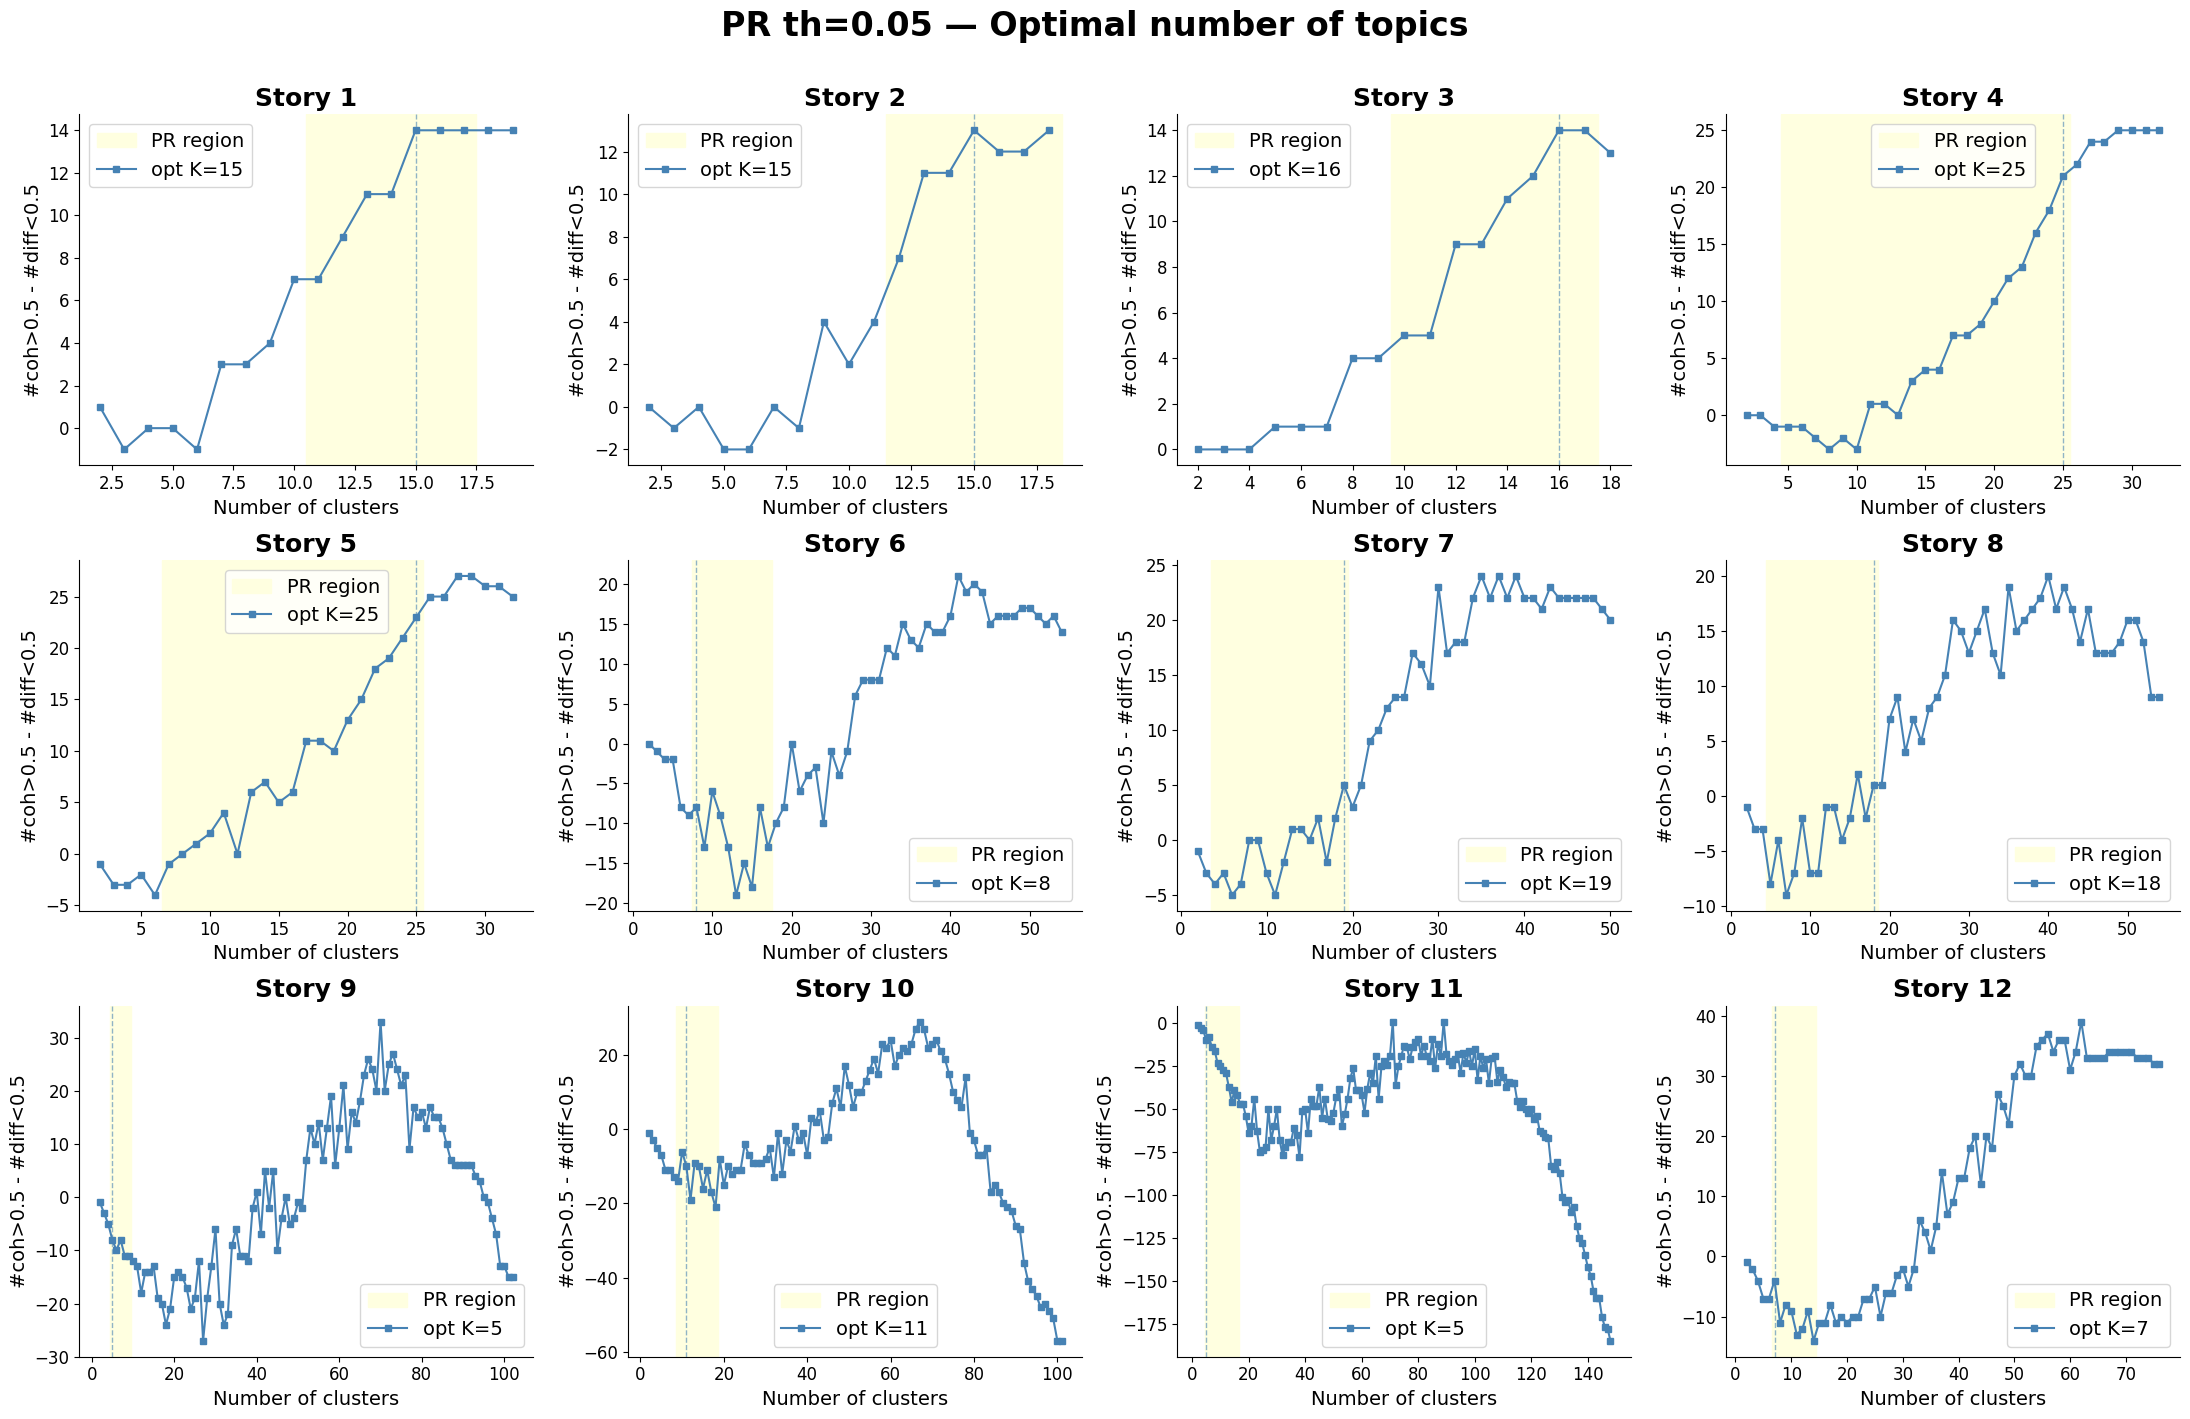

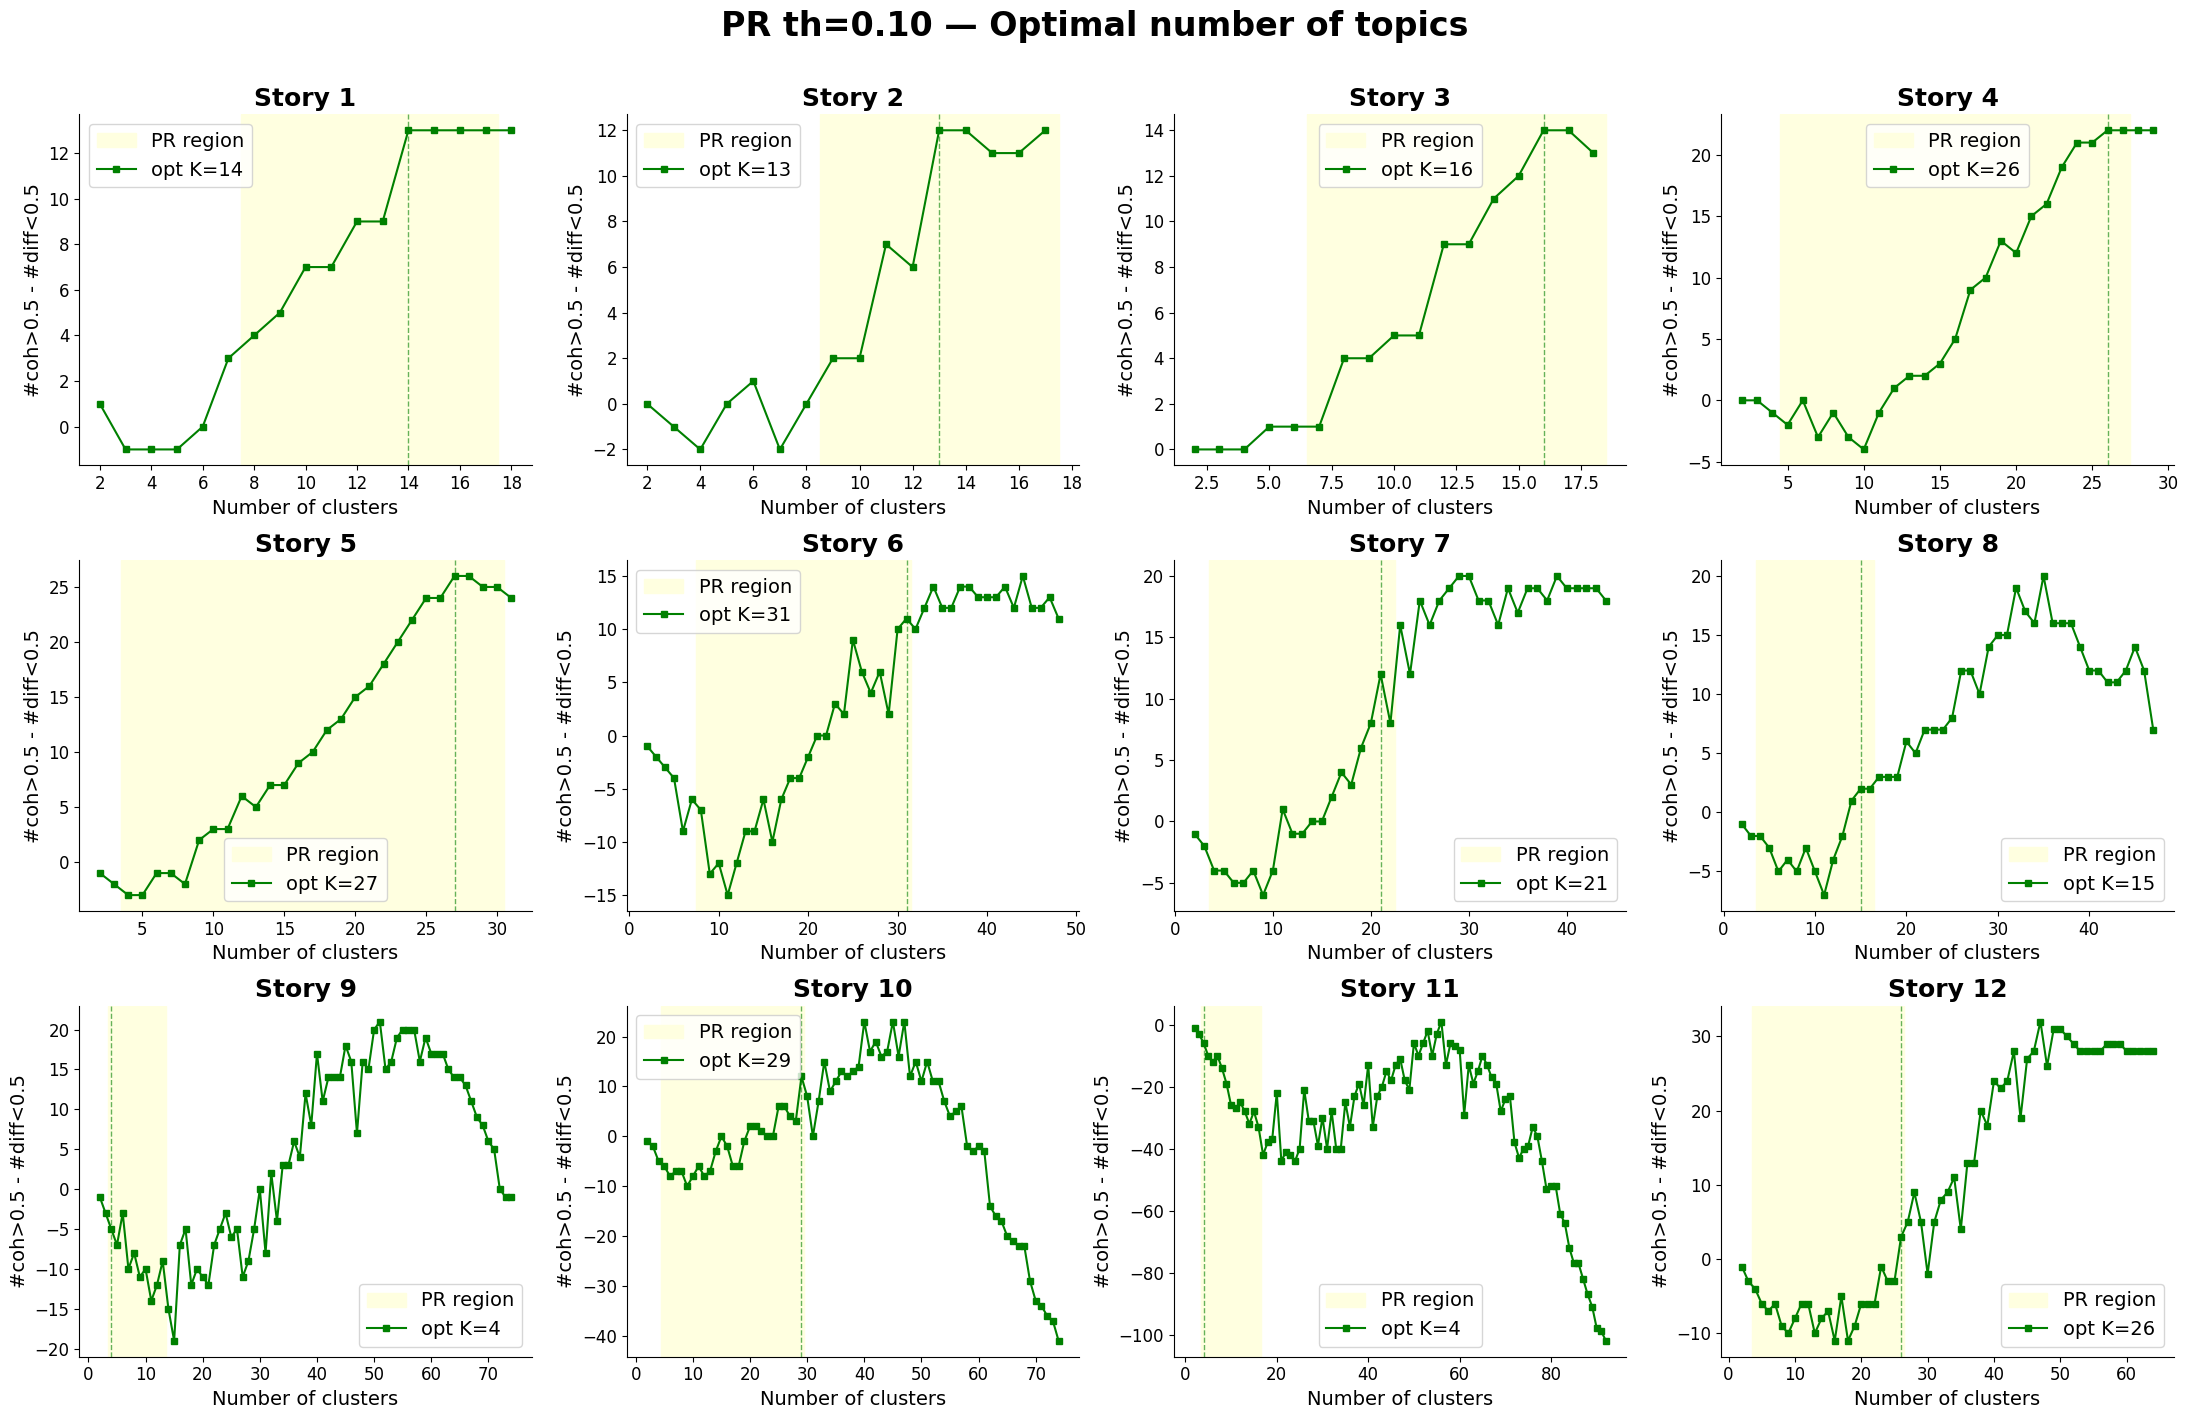

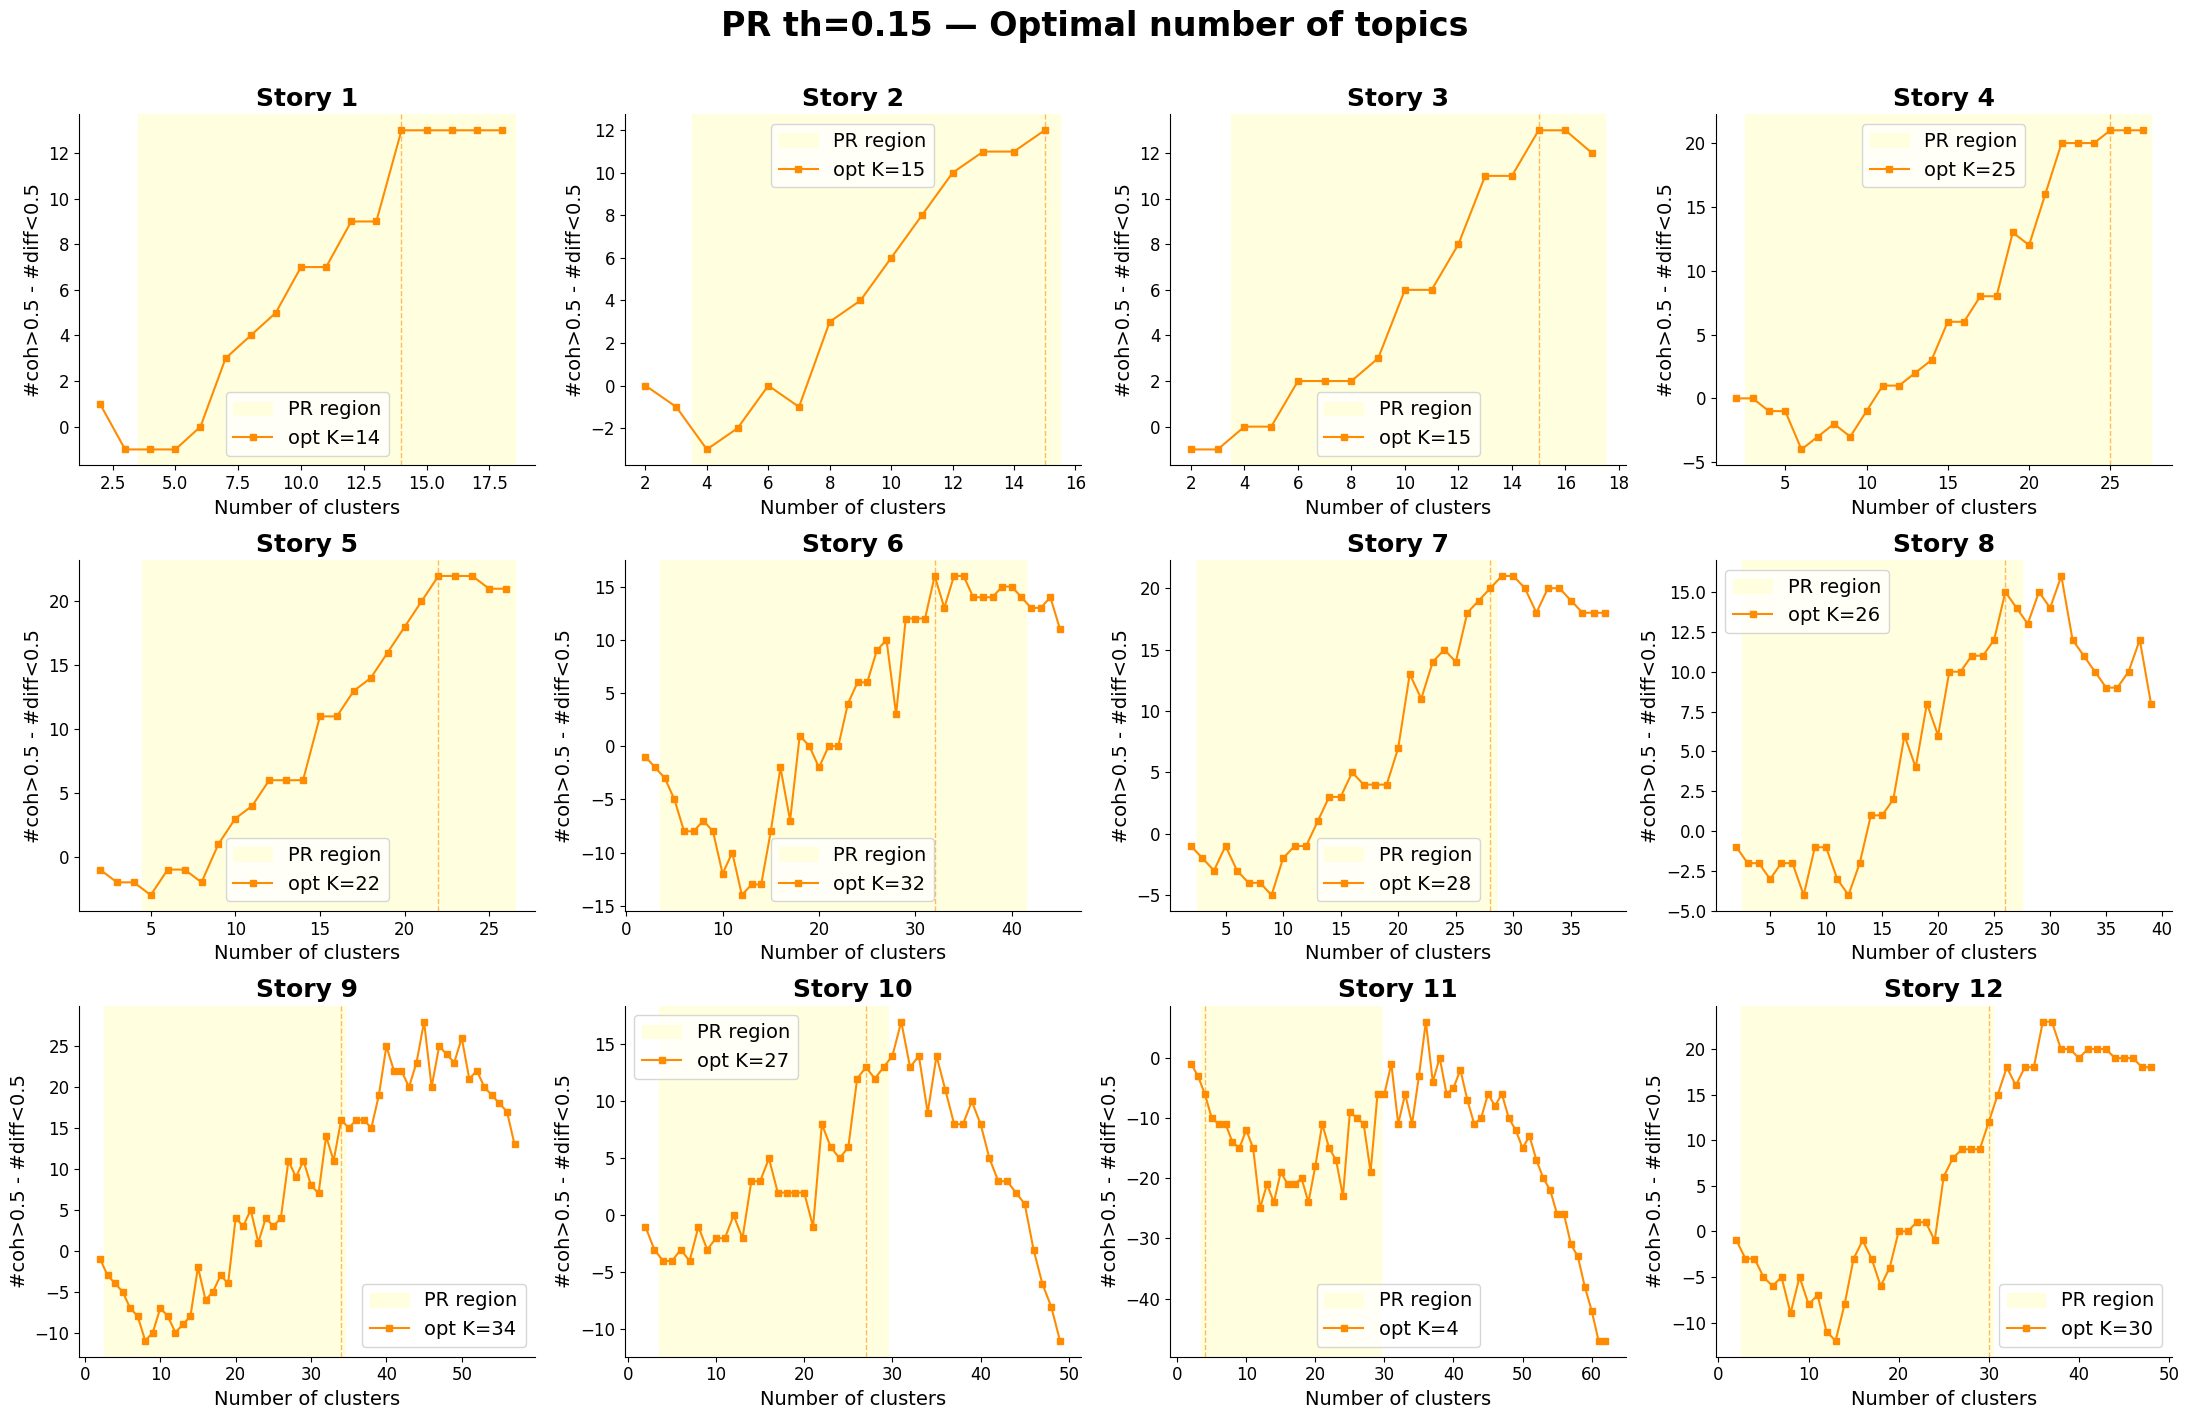

In [44]:
colors = {0.05: 'steelblue', 0.10: 'green', 0.15: 'darkorange'}

for th in thresholds:
    inner_fig, axes = plt.subplots(3, 4, figsize=(22, 14))
    axes = axes.flatten()

    for story in range(12):
        ax = axes[story]
        clauses_select = results[th]['clauses_select']
        k_range        = list(range(2, clauses_select[story] + 1))
        combined       = kmeans_results[th]['combined_all_narratives'][story]
        optimal_n      = pr_results[th]['optimal_n_all'][story]
        k_in_region    = pr_results[th]['story_results'][story]['k_in_pr_region']

        # shade PR candidate region
        ax.axvspan(min(k_in_region) - 0.5, max(k_in_region) + 0.5,
                   color='lightyellow', zorder=0, label='PR region')

        ax.plot(k_range, combined, 's-', color=colors[th], lw=1.5,
                markersize=4, label=f"opt K={optimal_n}", zorder=2)
        ax.axvline(x=optimal_n, color=colors[th], linestyle='--', lw=1,
                   alpha=0.6, zorder=3)

        ax.set_title(f"Story {story+1}", fontsize=18, fontweight='bold')
        ax.set_xlabel("Number of clusters", fontsize=14)
        ax.set_ylabel("#coh>0.5 - #diff<0.5", fontsize=14)
        ax.tick_params(labelsize=12)
        ax.legend(fontsize=14)
        ax.spines[['top', 'right']].set_visible(False)

    inner_fig.suptitle(f"PR th={th:.2f} — Optimal number of topics",
                       fontsize=24, fontweight='bold', y=1.01)
    inner_fig.tight_layout()
    inner_fig.show()


In [45]:
for story in range(12):
    print(f"\nNarrative {story+1}:")
    for th in thresholds:
        optimal_n     = pr_results[th]['optimal_n_all'][story]
        labels        = kmeans_results[th]['labels_all_narratives'][story][optimal_n - 2]
        cluster_sizes = [int(np.sum(labels == c)) for c in range(optimal_n)]
        print(f"  th={th:.2f}  optimal K={optimal_n}: {cluster_sizes}")



Narrative 1:
  th=0.05  optimal K=15: [1, 2, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1]
  th=0.10  optimal K=14: [2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  th=0.15  optimal K=14: [2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Narrative 2:
  th=0.05  optimal K=15: [1, 3, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  th=0.10  optimal K=13: [1, 1, 4, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1]
  th=0.15  optimal K=15: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Narrative 3:
  th=0.05  optimal K=16: [2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  th=0.10  optimal K=16: [2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  th=0.15  optimal K=15: [1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Narrative 4:
  th=0.05  optimal K=25: [1, 4, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1]
  th=0.10  optimal K=26: [1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  th=0.15  optimal K=25: [1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Narr

In [46]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

story = 5

for th in thresholds:
    optimal_n    = pr_results[th]['optimal_n_all'][story]
    labels       = kmeans_results[th]['labels_all_narratives'][story][optimal_n - 2]
    selected_idx = results[th]['selected_indices_all'][story]

    rows = []
    for c in range(optimal_n):
        first = True
        for j, lbl in enumerate(labels):
            if lbl == c:
                idx = selected_idx[j]
                rows.append({
                    'Cluster': f"Cluster {c+1}" if first else '',
                    'Clause':  idx + 1,
                    'Text':    story_processed_all[story][idx],
                })
                first = False

    df = pd.DataFrame(rows)[['Cluster', 'Clause', 'Text']]

    def border_between_clusters(row):
        if row.name == 0:
            return [''] * len(row)
        if df.loc[row.name, 'Cluster'] != '':
            return ['border-top: 2px solid black'] * len(row)
        return [''] * len(row)

    print(f"\n── Story 6  th={th:.2f}  optimal K={optimal_n} ──")
    display(df.style.apply(border_between_clusters, axis=1).hide(axis='index'))



── Story 6  th=0.05  optimal K=8 ──


Cluster,Clause,Text
Cluster 1,3,"- working on the warehouse floor,"
,4,stocking boxes
,5,and organizing merchandise.
,12,"But then, as I was walking around the warehouse"
,13,"returning items to their proper places,"
,27,Suddenly I heard a voice coming from across the warehouse.
Cluster 2,7,and it was getting late.
,10,but chalked it up to hunger
,11,and not having eaten yet that day.
,18,but the pressure only got stronger.



── Story 6  th=0.10  optimal K=31 ──


Cluster,Clause,Text
Cluster 1,7,and it was getting late.
Cluster 2,19,And I could feel my heart pounding in my chest.
,21,and I could feel sweat dripping down my forehead
,36,and I could feel my world going dark.
Cluster 3,25,I was really scared
,49,"It turned out I had been having a panic attack,"
Cluster 4,30,and called out to me
,39,and caught me just before my legs gave out.
,41,and sat me down in a chair.
Cluster 5,3,"- working on the warehouse floor,"



── Story 6  th=0.15  optimal K=32 ──


Cluster,Clause,Text
Cluster 1,12,"But then, as I was walking around the warehouse"
,27,Suddenly I heard a voice coming from across the warehouse.
Cluster 2,45,and told me to rest for a bit
,55,and make sure to properly rest
Cluster 3,32,and was checking to see if I was alright.
,41,and sat me down in a chair.
,54,and it taught me to check in with myself
Cluster 4,28,"It was the manager,"
,35,The manager started walking towards me
,38,but luckily the manager got to me in time


## Run the optimal topics in the tree model, and compare their statistics.

In [48]:
import math
import random

# ── parameters ────────────────────────────────────────────────────────────────
partition_bars = 3
groups         = partition_bars + 1

# ── core functions ────────────────────────────────────────────────────────────
def ball_location_simulation(parent_clause):
    num_locations = parent_clause + partition_bars
    bar_locations = random.sample(range(num_locations), k=partition_bars)
    assignment    = np.zeros(num_locations, dtype=int)
    assignment[bar_locations] = 1
    return assignment

def calculate_clauses(assignment):
    bar_indices = [i for i, v in enumerate(assignment) if v == 1]
    nodes       = [bar_indices[0]]
    nodes      += [bar_indices[i] - bar_indices[i-1] - 1 for i in range(1, len(bar_indices))]
    nodes      += [len(assignment) - 1 - bar_indices[-1]]
    return nodes

def count_calculate(parent_layer):
    count = 1
    for node in parent_layer:
        if node > 1:
            count *= math.comb(node + groups - 1, groups - 1)
    return count

def generate_branch_random(previous_layer):
    assignments = [ball_location_simulation(n) for n in previous_layer]
    new_layer   = [calculate_clauses(a) for a in assignments]
    return [n for branch in new_layer for n in branch]


In [49]:
## Theoretical value from equations.
N_all  = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]
scale = 0.01 * np.array([38.473684210526315, 43.452380952380956, 44.94444444444444,
                          35.125, 33.353960396039604, 41.107142857142854,
                          38.227513227513235, 37.72222222222222, 23.084693084693086,
                          33.85245901639344, 33.73240217270813, 25.30214424951267])
N_all = np.round(np.array(N_all) * scale).astype(int)
k      = 4
depths = [2, 3, 4, 5]

def z_func(k, n):
    return math.comb(n + k - 1, k - 1)

def T_matrix_func(k, N):
    T = np.zeros((N+1, N+1))
    for i in range(N+1):
        for j in range(i+1, N+1):
            T[i, j] = z_func(k-1, j-i) / z_func(k, j)
    return T

def P_1_func(N):
    P = np.zeros(N+1)
    P[N] = 1
    return P.reshape(-1, 1)

P_all = [[] for _ in range(12)]
x_all = [[] for _ in range(12)]

for story in range(12):
    N       = N_all[story]
    P_1     = P_1_func(N)
    T       = T_matrix_func(k, N)

    for depth in depths:
        P_D = np.linalg.matrix_power(T, depth) @ P_1
        P_D = P_D.reshape(1, -1)
        P_D = P_D / np.sum(P_D)                    # normalize to sum = 1
        P_D = P_D * (k ** (depth - 1))             # scale by number of chunks

        P_all[story].append(P_D)
        x_all[story].append(np.arange(1, N+2))


In [50]:
## get P(n) from topic-chunks, branching one more layer.
from collections import defaultdict

partition_bars = 3
groups         = partition_bars + 1
sim_times      = 500

avg_dict_all = {}   # keyed by [th][story]

for th in thresholds:
    avg_dict_all[th] = {}

    for story in range(12):
        optimal_k      = pr_results[th]['optimal_n_all'][story]
        labels         = kmeans_results[th]['labels_all_narratives'][story][optimal_k - 2]
        initial_clause = [int(np.sum(labels == c)) for c in range(optimal_k)]

        sim_recall_layer = [generate_branch_random(initial_clause) for _ in range(sim_times)]

        prob_data_all = []
        for layer in sim_recall_layer:
            layer_data = np.array(layer).flatten()
            unique, counts = np.unique(layer_data, return_counts=True)
            prob_dict = {int(val): count for val, count in zip(unique, counts) if val != 0}
            prob_data_all.append(prob_dict)

        values = defaultdict(list)
        for d in prob_data_all:
            for key, val in d.items():
                values[key].append(val)

        avg_dict_all[th][story] = {key: np.mean(vs) for key, vs in values.items()}
        print(f"th={th:.2f}  Story {story+1} done — optimal K={optimal_k}")

print(f"\nDone. Results stored in avg_dict_all[th][story].")


th=0.05  Story 1 done — optimal K=15
th=0.05  Story 2 done — optimal K=15
th=0.05  Story 3 done — optimal K=16
th=0.05  Story 4 done — optimal K=25
th=0.05  Story 5 done — optimal K=25
th=0.05  Story 6 done — optimal K=8
th=0.05  Story 7 done — optimal K=19
th=0.05  Story 8 done — optimal K=18
th=0.05  Story 9 done — optimal K=5
th=0.05  Story 10 done — optimal K=11
th=0.05  Story 11 done — optimal K=5
th=0.05  Story 12 done — optimal K=7
th=0.10  Story 1 done — optimal K=14
th=0.10  Story 2 done — optimal K=13
th=0.10  Story 3 done — optimal K=16
th=0.10  Story 4 done — optimal K=26
th=0.10  Story 5 done — optimal K=27
th=0.10  Story 6 done — optimal K=31
th=0.10  Story 7 done — optimal K=21
th=0.10  Story 8 done — optimal K=15
th=0.10  Story 9 done — optimal K=4
th=0.10  Story 10 done — optimal K=29
th=0.10  Story 11 done — optimal K=4
th=0.10  Story 12 done — optimal K=26
th=0.15  Story 1 done — optimal K=14
th=0.15  Story 2 done — optimal K=15
th=0.15  Story 3 done — optimal K=15
t

In [51]:
## put the results into a dictionary P(n). pad the shape.
flag = 1

padded_results = {}   # keyed by th

for th in thresholds:
    story_index_all   = []
    curve_value_dic   = []

    for story in range(12):
        story_index_all.append(story)
        curve_value_dic.append(avg_dict_all[th][story])

    # extract sorted values
    curve_value_raw = []
    for hist in curve_value_dic:
        sorted_keys = sorted(hist.keys())
        curve_value_raw.append([hist[k] for k in sorted_keys])

    # y and x values
    curve_value_histo = [list(v) for v in curve_value_raw]
    x_value_scaled    = [list(np.arange(1, len(v) + 1)) for v in curve_value_raw]

    # pad to same length
    max_len  = max(len(s) for s in curve_value_histo)
    y_padded = np.array([s + [s[-1]] * (max_len - len(s)) for s in curve_value_histo])

    x_padded = []
    for sublist in x_value_scaled:
        current_len = len(sublist)
        if current_len < max_len:
            extension = list(np.arange(sublist[-1] + 1, sublist[-1] + 1 + (max_len - current_len)))
            x_padded.append(np.array(sublist + extension))
        else:
            x_padded.append(np.array(sublist))
    x_padded = np.array(x_padded)

    padded_results[th] = {
        'story_index_all':   story_index_all,
        'curve_value_dic':   curve_value_dic,
        'curve_value_histo': curve_value_histo,
        'x_value_scaled':    x_value_scaled,
        'y_padded':          y_padded,
        'x_padded':          x_padded,
    }
    print(f"th={th:.2f} done — 12 stories, max_len={max_len}")


th=0.05 done — 12 stories, max_len=40
th=0.10 done — 12 stories, max_len=28
th=0.15 done — 12 stories, max_len=23


In [52]:
## load the experiment data.
with open("recall_data_4tree.json", "r") as f:
    clause_compress_data = json.load(f)


In [53]:
## Prepare simulation data.
from collections import Counter

def flatten(sublist):
    result = []
    for item in sublist:
        if isinstance(item, list):
            result.extend(item)
        else:
            result.append(item)
    return result

def compute_mean_std(prob_dicts):
    max_key    = max(k for d in prob_dicts for k in d)
    all_keys   = np.arange(1, max_key + 1)
    values_list = [[d.get(k, 0) for k in all_keys] for d in prob_dicts]
    mean_dict  = {k: v for k, v in zip(all_keys, np.mean(values_list, axis=0))}
    std_dict   = {k: v for k, v in zip(all_keys, np.std(values_list,  axis=0))}
    return mean_dict, std_dict

def pad_to_length(sublists, max_len, pad_with_last=True):
    padded = []
    for s in sublists:
        if len(s) < max_len:
            pad = [s[-1]] * (max_len - len(s)) if pad_with_last else [0] * (max_len - len(s))
            padded.append(np.concatenate([s, pad]))
        else:
            padded.append(np.array(s))
    return np.array(padded)

# ── per-story mean and std across participants ────────────────────────────────
prob_dicts_all = []
std_all        = []

for i in range(12):
    prob_dicts = []
    for sublist in clause_compress_data[i][0]:
        flat  = flatten(sublist)
        counts = Counter(v for v in flat if v != 0)
        prob_dicts.append(dict(counts))

    mean_dict, std_dict = compute_mean_std(prob_dicts)
    prob_dicts_all.append(mean_dict)
    std_all.append(std_dict)

# ── extract x, y, std ────────────────────────────────────────────────────────
x_scaled_all   = [sorted(d.keys())           for d in prob_dicts_all]
y_scaled_all   = [[d[k] for k in sorted(d.keys())] for d in prob_dicts_all]
std_scaled_all = [[d[k] for k in sorted(d.keys())] for d in std_all]

# ── pad all stories to the same length ───────────────────────────────────────
max_len = max(len(s) for s in y_scaled_all)

y_padded_experiment   = pad_to_length(y_scaled_all,   max_len)
std_padded_experiment = pad_to_length(std_scaled_all, max_len)
x_padded_experiment   = pad_to_length(
    [np.array(s, dtype=float) for s in x_scaled_all], max_len, pad_with_last=True)


#### Plot.

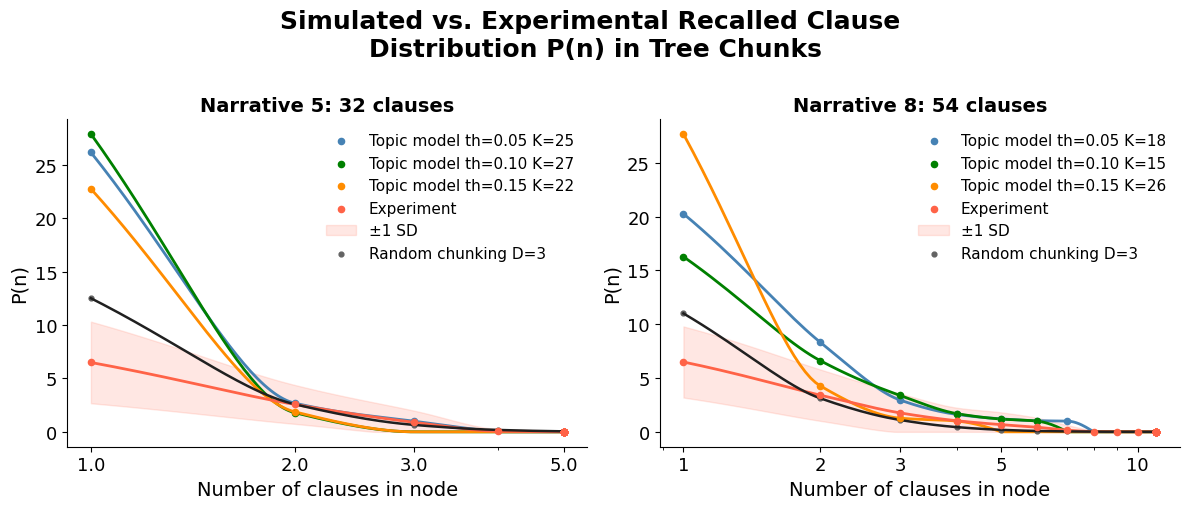

In [59]:
## draw an example plot.
from matplotlib.ticker import LogLocator, ScalarFormatter

colors_theory = ['#bdbdbd', '#636363']
colors_th     = {0.05: 'steelblue', 0.10: 'green', 0.15: 'darkorange'}
indices       = [4, 7]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Simulated vs. Experimental Recalled Clause \nDistribution P(n) in Tree Chunks",
             fontsize=18, fontweight='bold', y=1.01)

for ax, i in zip(axes, indices):
    fit_max  = float(np.max(experiment_x[i]))
    fit_min  = float(np.min(experiment_x[i]))
    x_smooth = np.linspace(fit_min, fit_max, 200)

    # ── Simulated — three thresholds ──────────────────────────────────────────
    for th in thresholds:
        best_k      = pr_results[th]['optimal_n_all'][i]
        avg_dict    = avg_dict_all[th][i]
        sorted_keys = sorted(avg_dict.keys())
        sim_x       = np.array(sorted_keys)
        sim_y       = np.array([avg_dict[k] for k in sorted_keys])

        fit_min  = float(max(np.min(experiment_x[i]), np.min(sim_x)))
        x_smooth = np.linspace(fit_min, fit_max, 200)

        y_sim    = pchip_smooth(sim_x, sim_y, x_smooth)
        mask_sim = sim_x <= fit_max
        ax.scatter(sim_x[mask_sim], sim_y[mask_sim],
                   marker='o', color=colors_th[th], s=20, zorder=3,
                   label=f'Topic model th={th:.2f} K={best_k}')
        ax.plot(x_smooth, y_sim, '-', color=colors_th[th], lw=2.0)

    # ── Experiment ────────────────────────────────────────────────────────────
    x_smooth = np.linspace(fit_min, fit_max, 200)
    y_exp    = pchip_smooth(experiment_x[i], experiment_data[i], x_smooth)
    y_std_hi = pchip_smooth(experiment_x[i], experiment_data[i] + std_padded_experiment[i], x_smooth)
    y_std_lo = pchip_smooth(experiment_x[i], experiment_data[i] - std_padded_experiment[i], x_smooth)
    ax.scatter(experiment_x[i], experiment_data[i],
               marker='o', color='tomato', s=20, zorder=3, label='Experiment')
    ax.plot(x_smooth, y_exp, '-', color='tomato', lw=2.0)
    ax.fill_between(x_smooth, y_std_lo, y_std_hi, color='tomato', alpha=0.15, label='±1 SD')

    # ── Theoretical (d=3, index 1) ────────────────────────────────────────────
    mask2 = np.array(x_all[i][1]) <= fit_max
    y2    = pchip_smooth(x_all[i][1], P_all[i][1][0], x_smooth)
    ax.scatter(np.array(x_all[i][1])[mask2], np.array(P_all[i][1][0])[mask2],
               marker='o', color=colors_theory[1], s=12, zorder=2, label='Random chunking D=3')
    ax.plot(x_smooth, y2, '-', color='#202020', lw=1.8)

    # ── Styling ───────────────────────────────────────────────────────────────
    ax.set_title(f'Narrative {i+1}: {clauses[i]} clauses', fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 3, 5]))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.tick_params(labelsize=13)
    ax.set_xlabel('Number of clauses in node', fontsize=14)
    ax.set_ylabel('P(n)', fontsize=14)
    ax.legend(fontsize=11, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()



In [60]:
def multinomial_loglik(observed, model_probs):
    obs  = np.array(observed, dtype=float)
    prob = np.array(model_probs, dtype=float)
    n    = min(len(obs), len(prob))
    obs  = obs[:n];  prob = prob[:n]
    prob = np.where(prob <= 0, 1e-10, prob)
    prob = prob / prob.sum()
    return np.sum(obs * np.log(prob))

def aic(ll, k):    return -2 * ll + 2 * k
def bic(ll, k, n): return -2 * ll + k * np.log(n)

aic_bic_results = {}

for th in thresholds:
    rows = []
    for story in range(12):
        optimal_k = pr_results[th]['optimal_n_all'][story]

        # experiment observed counts (aligned to integer x)
        obs_x   = x_padded_experiment[story].astype(int)
        obs_y   = y_padded_experiment[story]
        n_obs   = np.sum(obs_y)

        # ── topic model probabilities ──────────────────────────────────────
        avg_dict    = avg_dict_all[th][story]
        sorted_keys = sorted(avg_dict.keys())
        sim_x       = np.array(sorted_keys)
        sim_y       = np.array([avg_dict[k] for k in sorted_keys])

        # align sim to obs x range
        sim_dict  = dict(zip(sim_x, sim_y))
        sim_probs = np.array([sim_dict.get(x, 1e-10) for x in obs_x])

        # ── random model probabilities (d=3, index 1) ─────────────────────
        rand_x    = np.array(x_all[story][1]).flatten().astype(int)
        rand_y    = np.array(P_all[story][1][0]).flatten()
        rand_dict = dict(zip(rand_x, rand_y))
        rand_probs = np.array([rand_dict.get(x, 1e-10) for x in obs_x])

        # ── log-likelihoods ───────────────────────────────────────────────
        ll_topic  = multinomial_loglik(obs_y, sim_probs)
        ll_random = multinomial_loglik(obs_y, rand_probs)

        # k params: topic = optimal_k - 1, random = 0 (fully specified)
        k_topic  = optimal_k - 1
        k_random = 0

        rows.append({
            'Story':       story + 1,
            'Optimal K':   optimal_k,
            'LL Topic':    round(ll_topic,  2),
            'LL Random':   round(ll_random, 2),
            'AIC Topic':   round(aic(ll_topic,  k_topic),         2),
            'AIC Random':  round(aic(ll_random, k_random),        2),
            'BIC Topic':   round(bic(ll_topic,  k_topic,  n_obs), 2),
            'BIC Random':  round(bic(ll_random, k_random, n_obs), 2),
            'ΔAIC':        round(aic(ll_topic, k_topic) - aic(ll_random, k_random), 2),
            'ΔBIC':        round(bic(ll_topic, k_topic, n_obs) - bic(ll_random, k_random, n_obs), 2),
        })

    aic_bic_results[th] = pd.DataFrame(rows)
    print(f"\n── th={th:.2f} ──")
    display(aic_bic_results[th].set_index('Story'))



── th=0.05 ──


,Optimal K,LL Topic,LL Random,AIC Topic,AIC Random,BIC Topic,BIC Random,ΔAIC,ΔBIC
Story,,,,,,,,,
1,15,-72.06,-20.80,172.11,41.61,173.89,41.61,130.50,132.28
2,15,-40.41,-14.91,108.83,29.81,110.82,29.81,79.02,81.01
3,16,-84.81,-23.71,199.63,47.41,202.84,47.41,152.21,155.43
4,25,-45.53,-43.83,139.07,87.66,159.14,87.66,51.41,71.48
5,25,-20.88,-12.47,89.76,24.94,97.91,24.94,64.82,72.98
6,8,-36.08,-27.80,86.16,55.61,90.75,55.61,30.55,35.14
7,19,-32.87,-24.76,101.74,49.52,114.18,49.52,52.22,64.65
8,18,-29.37,-25.59,92.73,51.17,103.92,51.17,41.56,52.75
9,5,-56.29,-35.77,120.59,71.55,124.09,71.55,49.04,52.54



── th=0.10 ──


,Optimal K,LL Topic,LL Random,AIC Topic,AIC Random,BIC Topic,BIC Random,ΔAIC,ΔBIC
Story,,,,,,,,,
1,14,-71.85,-20.80,169.69,41.61,171.34,41.61,128.09,129.74
2,13,-39.28,-14.91,102.56,29.81,104.27,29.81,72.75,74.46
3,16,-84.92,-23.71,199.83,47.41,203.05,47.41,152.42,155.63
4,26,-201.22,-43.83,452.45,87.66,473.35,87.66,364.79,385.69
5,27,-42.12,-12.47,136.24,24.94,145.08,24.94,111.31,120.14
6,31,-101.32,-27.80,262.64,55.61,282.30,55.61,207.03,226.69
7,21,-41.83,-24.76,123.67,49.52,137.49,49.52,74.14,87.96
8,15,-32.31,-25.59,92.62,51.17,101.84,51.17,41.45,50.66
9,4,-57.28,-35.77,120.55,71.55,123.18,71.55,49.00,51.63



── th=0.15 ──


,Optimal K,LL Topic,LL Random,AIC Topic,AIC Random,BIC Topic,BIC Random,ΔAIC,ΔBIC
Story,,,,,,,,,
1,14,-71.82,-20.80,169.64,41.61,171.29,41.61,128.03,129.68
2,15,-79.58,-14.91,187.17,29.81,189.16,29.81,157.36,159.35
3,15,-84.53,-23.71,197.06,47.41,200.06,47.41,149.65,152.64
4,25,-201.09,-43.83,450.17,87.66,470.24,87.66,362.51,382.58
5,22,-41.39,-12.47,124.79,24.94,131.92,24.94,99.85,106.98
6,32,-102.19,-27.80,266.38,55.61,286.69,55.61,210.77,231.08
7,28,-130.55,-24.76,315.09,49.52,333.75,49.52,265.57,284.23
8,26,-59.87,-25.59,169.73,51.17,186.19,51.17,118.56,135.02
9,34,-101.56,-35.77,269.13,71.55,298.05,71.55,197.58,226.50
